In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [141]:
#pytorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [164]:
#load and visualsie dataset
image_dir = "../data/segmentation/images"
mask_dir = "../data/segmentation/masks"

images = os.listdir(image_dir)

print("Total images:", len(images))

Total images: 588


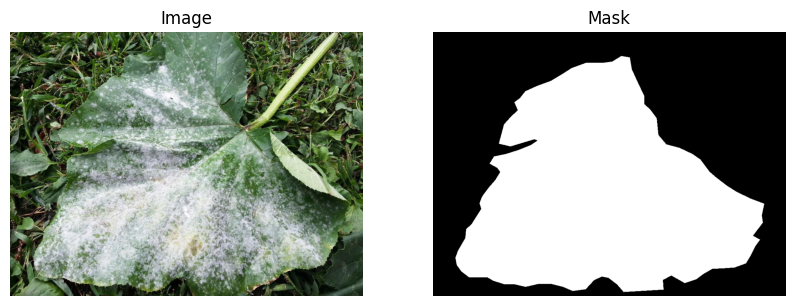

In [165]:
#show sample + image mask
img_name = images[0]

img_path = os.path.join(image_dir, img_name)
mask_path = os.path.join(mask_dir, img_name.replace(".jpg", ".png"))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

mask = cv2.imread(mask_path, 0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [5]:
#define u net model
import torch
import torch.nn as nn

In [6]:
# double convolution block 
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [7]:
# full U net
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, 2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

In [8]:
# initialize model
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=3, out_channels=1).to(device)

print("Model loaded on:", device)

Model loaded on: cpu


In [18]:
# dataset class
from torch.utils.data import Dataset, DataLoader
import cv2
import os
import numpy as np

In [162]:
# custom dataset 

class BinarySegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.replace(".jpg", ".png"))

        # read image and mask
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)

        # resize
        image = cv2.resize(image, (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        # normalize image
        image = image / 255.0
        
        # Convert to binary: 0 for background, 1 for any foreground class
        mask = (mask > 0).astype(np.float32)  # Any non-zero becomes 1

        # convert image format HWC → CHW
        image = np.transpose(image, (2, 0, 1))

        # convert to tensors
        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # Add channel dim

        return image, mask

In [156]:
# create dataloader
image_dir = "../data/segmentation/images"
mask_dir = "../data/segmentation/masks"

dataset = SegmentationDataset(image_dir, mask_dir)

loader = DataLoader(dataset, batch_size=4, shuffle=True)

In [157]:
imgs, masks = next(iter(loader))

print(imgs.shape)
print(masks.shape)

torch.Size([4, 3, 256, 256])
torch.Size([4, 1, 256, 256])


In [158]:
# train u net  loss function 
import torch.nn as nn
import torch.optim as optim



In [159]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [160]:
images, masks = next(iter(loader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([4, 1, 256, 256])


In [117]:
#training loop
num_epochs = 1

model.train()

for epoch in range(num_epochs):

    for batch_idx, (images, masks) in enumerate(loader):

        images = images.to(device)
        masks = masks.to(device)

        # forward pass
        outputs = model(images)

        # compute loss
        loss = criterion(outputs, masks)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Batch {batch_idx} Loss: {loss.item():.4f}")

        # stop early for testing
        if batch_idx == 5:
            break

Batch 0 Loss: 0.0308
Batch 1 Loss: 0.0134
Batch 2 Loss: 0.0061
Batch 3 Loss: 0.0007
Batch 4 Loss: 0.0004
Batch 5 Loss: 0.0000


In [52]:
# full training loop ,optimized
num_epochs = 5

model.train()

for epoch in range(num_epochs):

    epoch_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        # forward
        outputs = model(images)

        # loss
        loss = criterion(outputs, masks)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}")

Epoch [1/5] Average Loss: 0.1045
Epoch [2/5] Average Loss: 0.1013
Epoch [3/5] Average Loss: 0.1002
Epoch [4/5] Average Loss: 0.1017
Epoch [5/5] Average Loss: 0.1008


In [53]:
# evaluation 
model.eval()

UNet(
  (enc1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(512, 

In [54]:
# one sample
image, mask = dataset[0]

input_image = image.unsqueeze(0).to(device)

In [166]:
# predict mask
with torch.no_grad():
    pred_mask = model(input_image)

pred_mask = torch.sigmoid(pred_mask)
pred_mask = pred_mask.squeeze().cpu().numpy()

In [149]:
#convert original image 
image_np = image.permute(1, 2, 0).numpy()
if isinstance(mask, torch.Tensor):
    mask_np = mask.squeeze().cpu().numpy()
else:
    mask_np = mask.squeeze()

In [133]:
dataset = SegmentationDataset(image_dir, mask_dir)
loader = DataLoader(dataset, batch_size=4, shuffle=True)
print("eeere")

eeere


In [199]:

# ioU Dice function
import torch
def iou_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + 1e-6) / (union + 1e-6)


def dice_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()

    return (2 * intersection + 1e-6) / (pred.sum() + target.sum() + 1e-6)

In [201]:
# Your model returns a dict, you need to extract 'out'
model.eval()

iou_total = 0
dice_total = 0

with torch.no_grad():
    for i in range(50):
        image, mask = dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        # Get prediction - FCN model returns dictionary
        output = model(image)
        
        # Extract the actual prediction tensor
        if isinstance(output, dict):
            pred = output['out']  # Key for the main output
        else:
            pred = output
        
        iou_total += iou_score(pred, mask).item()
        dice_total += dice_score(pred, mask).item()

print("Mean IoU:", iou_total / 50)
print("Mean Dice:", dice_total / 50)

Mean IoU: 0.1785963630862534
Mean Dice: 0.27482870226725936


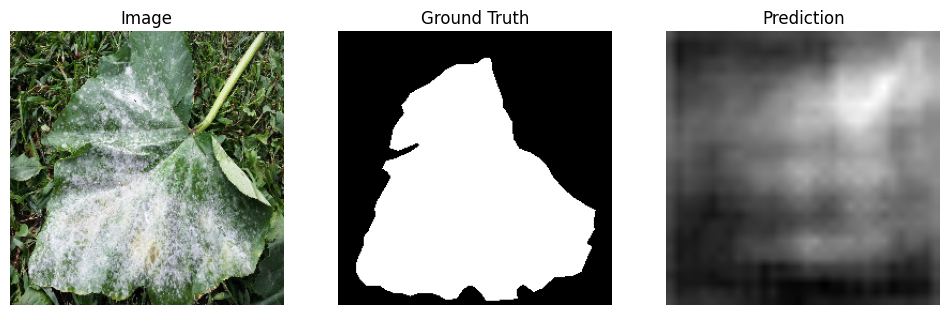

Prediction range: [0.494, 0.658]
Prediction mean: 0.558


In [203]:
import matplotlib.pyplot as plt

model.eval()

image, mask = dataset[0]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    
    # Extract the tensor from the OrderedDict
    if isinstance(output, dict) or isinstance(output, OrderedDict):
        pred = output['out']  # Get the actual prediction tensor
    else:
        pred = output
    
    pred = torch.sigmoid(pred)

pred = pred.squeeze().cpu().numpy()
mask = mask.squeeze().cpu().numpy()

image_np = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np)
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

print(f"Prediction range: [{pred.min():.3f}, {pred.max():.3f}]")
print(f"Prediction mean: {pred.mean():.3f}")

In [207]:
def precision_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()

    return (tp + 1e-6) / (tp + fp + 1e-6)


def recall_score(pred, target):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    tp = (pred * target).sum()
    fn = ((1 - pred) * target).sum()

    return (tp + 1e-6) / (tp + fn + 1e-6)

In [211]:
model.eval()

iou_total = 0
dice_total = 0
precision_total = 0
recall_total = 0

with torch.no_grad():
    for i in range(50):
        image, mask = dataset[i]

        image = image.unsqueeze(0).to(device)
        mask = mask.unsqueeze(0).to(device)

        outputs = model(image)
        pred = outputs["out"]   # ✅ FIXED HERE

        iou_total += iou_score(pred, mask).item()
        dice_total += dice_score(pred, mask).item()
        precision_total += precision_score(pred, mask).item()
        recall_total += recall_score(pred, mask).item()

print("Mean IoU:", iou_total / 50)
print("Mean Dice:", dice_total / 50)
print("Mean Precision:", precision_total / 50)
print("Mean Recall:", recall_total / 50)

Mean IoU: 0.1785963630862534
Mean Dice: 0.27482870226725936
Mean Precision: 0.18609223478473724
Mean Recall: 0.8937110130488872


In [216]:
torch.save(
    model,
    "/Users/jiheneguesmi/Desktop/machine_learning/smart_agriculture/notebooks/runs/full_model.pth"
)

In [215]:
state = torch.load("unet_model.pth", map_location="cpu")

print(type(state))
print(list(state.keys())[:10])

<class 'collections.OrderedDict'>
['backbone.conv1.weight', 'backbone.bn1.weight', 'backbone.bn1.bias', 'backbone.bn1.running_mean', 'backbone.bn1.running_var', 'backbone.bn1.num_batches_tracked', 'backbone.layer1.0.conv1.weight', 'backbone.layer1.0.bn1.weight', 'backbone.layer1.0.bn1.bias', 'backbone.layer1.0.bn1.running_mean']
